In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

FPS = 29.97

Saving seganymo_tracks.csv to seganymo_tracks (1).csv


In [50]:
# Density-Based Spatial Clustering of Applications with Noise
from sklearn.cluster import DBSCAN
EPS = 70
df = pd.read_csv("seganymo_tracks.csv")

if "chunk_id" in df.columns:
    frames_per_chunk = df["frame"].max() + 1
    tracks_per_chunk = df["track_id"].max() + 1

    frame_offset = (df["chunk_id"] - 1) * frames_per_chunk
    track_offset = df["chunk_id"] * tracks_per_chunk

    df["frame"] = frame_offset + df["frame"]
    df["track_id"] = track_offset + df["track_id"]

    overlap = df.duplicated(subset=["track_id", "frame"]).any()
    assert not overlap, "track-frame pairs overlap across chunks"

vis = df[df["visible"] == True]
vis = vis[vis["x"].notna()]

track_to_obj = {}
assignments = {}
next_obj = 0

for frame_number in sorted(vis["frame"].unique()):
  sub = vis[vis["frame"] == frame_number]

  points = sub[["x", "y"]].values
  labels = DBSCAN(eps=EPS, min_samples = 1).fit_predict(points)

  clusters = {}
  for track_id, label in zip(sub["track_id"].values, labels):
    if label not in clusters:
      clusters[label] = []
    clusters[label].append(track_id)

  cluster_info = []
  for label, members in clusters.items():
    votes = {}
    for t in members:
      if t in track_to_obj:
        previous = track_to_obj[t]
        votes[previous] = votes.get(previous,0) + 1
    if len(votes) > 0:
      best_obj = max(votes, key=votes.get)
      best_count = votes[best_obj]
    else:
      best_obj = None
      best_count = 0
    cluster_info.append((best_count, label, best_obj))

  cluster_info.sort(reverse=True)
  used = set()
  for best_count, label, best_obj in cluster_info:
    if best_obj is None or best_obj in used:
      best_obj = next_obj
      next_obj = next_obj + 1
    used.add(best_obj)
    for t in clusters[label]:
      track_to_obj[t] = best_obj
      assignments[(frame_number, t)] = best_obj


df["obj"] = [
    assignments.get((f, t), -1)
    for f, t in zip(df["frame"], df["track_id"])
]

df.to_csv("dots_with_objects.csv", index=False)

In [51]:
df = pd.read_csv("dots_with_objects.csv")
print(df.head())

   track_id  frame          x          y  visible      conf     t_sec  \
0       299      0  402.60672  204.64302     True  0.957295  0.000000   
1       299      1  400.12192  197.49138     True  0.962544  0.033367   
2       299      2  396.46246  190.64542     True  0.965413  0.066733   
3       299      3  392.53867  183.61095     True  0.964643  0.100100   
4       299      4  390.55823  175.12143     True  0.961606  0.133467   

         dx        dy   step_px      speed      accel   heading      turn  \
0       NaN       NaN       NaN        NaN        NaN       NaN       NaN   
1 -2.484802 -7.151642  7.571012  226.90346        NaN -1.905193       NaN   
2 -3.659454 -6.845962  7.762655  232.64699  172.13377 -2.061694 -0.156501   
3 -3.923798 -7.034470  8.054810  241.40288  262.41428 -2.079605 -0.017911   
4 -1.980438 -8.489517  8.717456  261.26242  595.19110 -1.799978  0.279627   

   chunk_id  obj  
0         1    2  
1         1    2  
2         1    2  
3         1    2  
4  

In [52]:
CHUNK_LEN = 100
df["frame"] = (df["chunk_id"] - 1) * CHUNK_LEN + df["frame"]   # 0..570, global
df["track_id"] = df["chunk_id"] * 1000 + df["track_id"]         # unique per chunk

In [53]:
df = df[df["visible"] == True]
df = df[df["x"].notna()]
df["obj"] = df["obj"].astype(int)
print("visible rows:", len(df))
print("number of tracks:", df["track_id"].nunique())
print("number of objects:", df["obj"].unique())

visible rows: 27540
number of tracks: 1405
number of objects: [  2  15  18  19   3  23  25   1   5   4  22  27  28  24   7  10  26  11
  13  14  16   9  12  20   0   8  21   6  17  32  34  29  35  39  42  45
  49  30  40  47  57  63  66  61  62  58  46  51  50  56  48  55  41  31
  37  54  33  59  36  44  65  53  43  52  64  38  60  88 106  95  69  92
  74  72 109  79  82  85  68 100 103  70  99  76 104  71  98 107  91  80
  97  77  84  87  89 102 110  67 108  94  83  86  73  96 101  93  90 105
  75  78  81 130 114 127 136 112 118 113 120 117 116 142 139 123 129 131
 143 125 126 128 135 132 149 133 124 147 115 146 144 140 137 119 134 141
 121 145 111 122 138 148 150 170 169 171 177 151 175 154 161 162 152 165
 160 166 167 178 176 164 157 180 158 159 173 168 155 179 163 156 172 153
 174 197 186 183 190 191 184 193 182 181 196 195 194 192 188 187 189 198
 185]


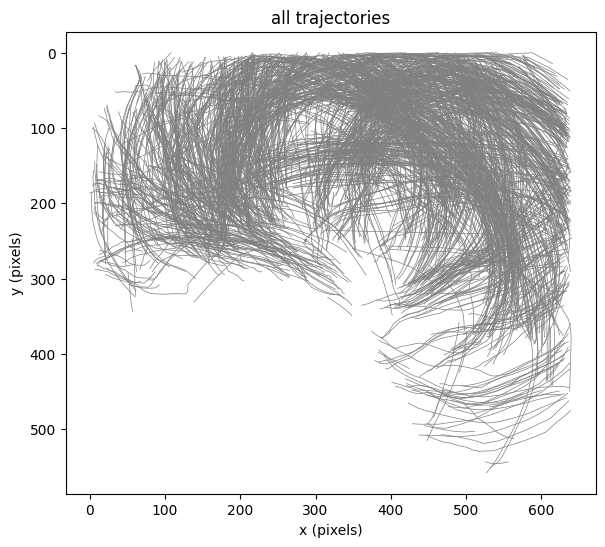

In [54]:
plt.figure(figsize=(7, 6))

for track_id, tr in df.groupby("track_id"):
    tr = tr.sort_values("frame")
    plt.plot(tr["x"], tr["y"], color="gray", linewidth=0.5)

plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")
plt.title("all trajectories")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.show()

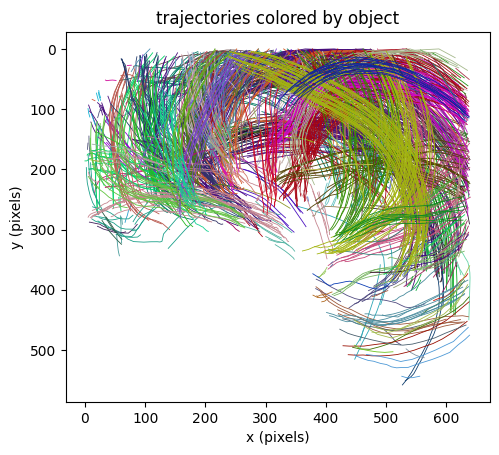

In [55]:
obj_color = {}
for o in df["obj"].unique():
  obj_color[o] = np.random.rand(3)*0.85

for (obj,track_id), tr in df.groupby(["obj","track_id"]):
  tr = tr.sort_values("frame")
  plt.plot(tr["x"], tr["y"], color=obj_color[obj], linewidth=0.6)

plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")
plt.title("trajectories colored by object")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.show()

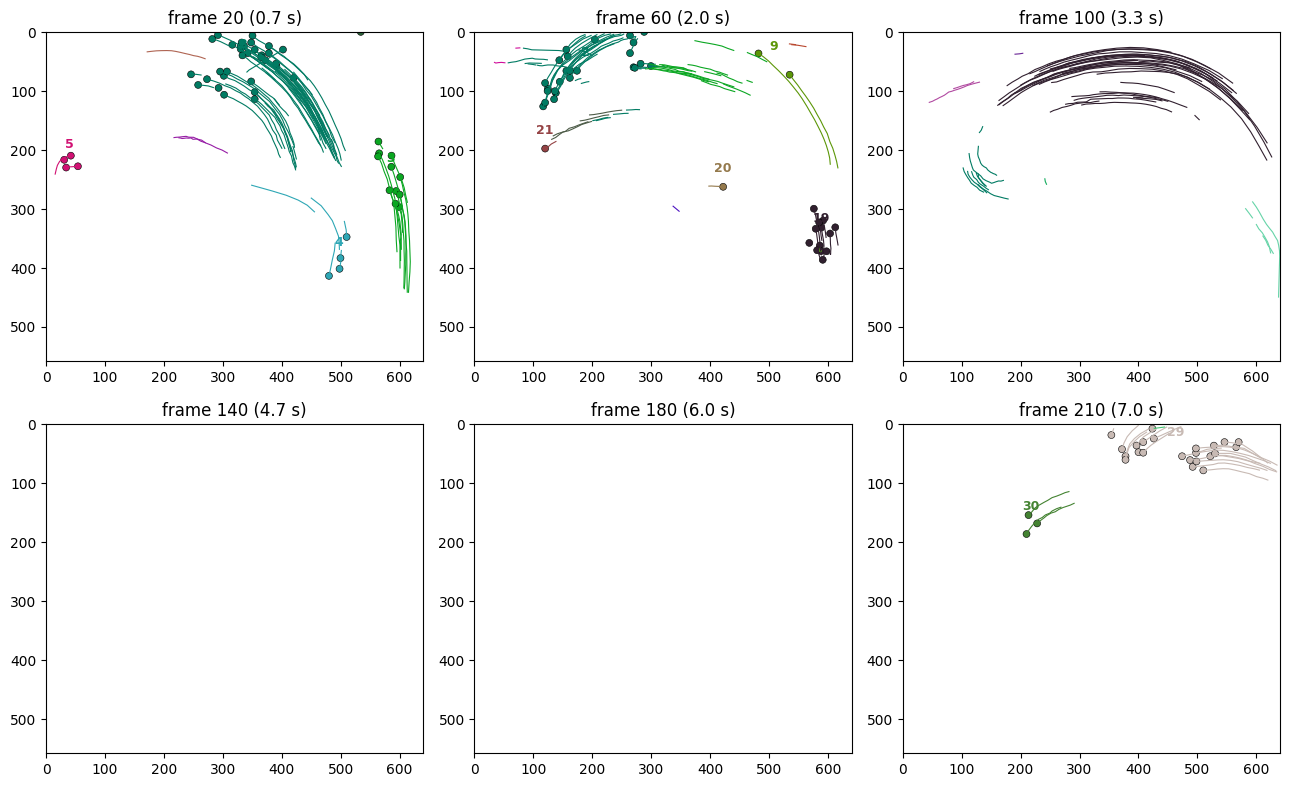

In [56]:
frames_to_show = [20, 60, 100, 140, 180, 210]
TRAIL = 20

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

x_min = df["x"].min()
x_max = df["x"].max()
y_min = df["y"].min()
y_max = df["y"].max()


for ax, F in zip(axes.flat, frames_to_show):

    recent = df[
        (df["frame"] > F - TRAIL) &
        (df["frame"] <= F)
    ]

    for (obj, track_id), tr in recent.groupby(["obj", "track_id"]):
        tr = tr.sort_values("frame")

        ax.plot(
            tr["x"],
            tr["y"],
            color=obj_color[obj],
            linewidth=0.8
        )

    current = recent[recent["frame"] == F]

    ax.scatter(
        current["x"],
        current["y"],
        c=[obj_color[obj] for obj in current["obj"]],
        s=25,
        edgecolors="black",
        linewidths=0.4
    )


    for obj, points in current.groupby("obj"):
        x_center = points["x"].mean()
        y_center = points["y"].mean()

        ax.annotate(
            obj,
            (x_center, y_center - 25),
            color=obj_color[obj],
            fontsize=9,
            fontweight="bold",
            ha="center"
        )

    ax.set_title(f"frame {F} ({F / FPS:.1f} s)")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)
    ax.set_aspect("equal")


plt.tight_layout()
plt.show()

In [57]:
from scipy.signal import savgol_filter

MAX_GAP = 3 # discontinue tracks if track disappears for # frames
MIN_LEN = 15 # min rows that are being assessed
SMOOTH = 9 # for filter
K_MIN = 0.004 # min_curvature
MIN_STEP = 3
TRAIL = 30
WAVY_MIN = 2
MIN_OBJ_FRAMES = 10

SPEED_MIN = 300 #SPEED



pieces = []

for track_id, track in df.groupby("track_id"):
    track = track.sort_values("frame").set_index("frame")

    #find gaps of track and split tracks
    split_points = np.where(
        np.diff(track.index) > MAX_GAP
    )[0] + 1

    for rows in np.split(np.arange(len(track)), split_points):   #split :)
        piece = track.iloc[rows].copy()

        # Fill small gaps in the track
        frames = range(
            piece.index.min(),
            piece.index.max() + 1
        )

        piece = piece.reindex(frames) #make continous frames

        # interpolation for missing values/frames
        piece[["x", "y", "speed"]] = (
            piece[["x", "y", "speed"]]
            .interpolate()
        )

        piece["track_id"] = track_id
        piece["obj"] = piece["obj"].ffill()

        pieces.append(piece.reset_index())

seg = pd.concat(pieces, ignore_index=True)

seg["piece"] = (
    seg.groupby("track_id")["frame"]
    .diff()
    .ne(1)
    .cumsum()
)


def curvature(x, y):
    #curvature calculation for scratching bahaviors, which are wavy, if k >0, then path changes direction
    dx = savgol_filter(x, SMOOTH, 3, deriv=1)
    dy = savgol_filter(y, SMOOTH, 3, deriv=1)

    ddx = savgol_filter(x, SMOOTH, 3, deriv=2)
    ddy = savgol_filter(y, SMOOTH, 3, deriv=2)

    #movement magnitude
    step = np.hypot(dx, dy)

    #calculating curvature
    k = (
        dx * ddy - dy * ddx
    ) / np.maximum(step, 1e-6) ** 3

    # ignore direction when movement is too slow
    k[step < MIN_STEP] = 0

    return k


def recent_flip_counts(signs):
    counts = []

    for i in range(len(signs)):
        window = signs[max(0, i - TRAIL + 1): i + 1]

        #ignore straight frames
        window = window[window != 0]

        flips = np.sum(np.diff(window) != 0)
        counts.append(int(flips))

    return counts


seg["flips_recent"] = np.nan

for _, piece in seg.groupby("piece"):
    if len(piece) < MIN_LEN:
        continue

    k = curvature(
        piece["x"].to_numpy(),
        piece["y"].to_numpy()
    )

    bend_sign = np.where(
        k > K_MIN,
        1,
        np.where(k < -K_MIN, -1, 0)
    )

    seg.loc[piece.index, "flips_recent"] = (
        recent_flip_counts(bend_sign)
    )

OBJ = (
    seg
    .dropna(subset=["flips_recent"])
    .groupby(["obj", "frame"])
    .agg(
        n_dots=("track_id", "size"),
        flips_med=("flips_recent", "median"),
        speed=("speed", "mean"),
    )
    .reset_index()
)

OBJ["obj"] = OBJ["obj"].astype(int)
OBJ["wavy"] = OBJ["flips_med"] >= WAVY_MIN
OBJ["scratch"] = OBJ["wavy"] & (OBJ["speed"] >= SPEED_MIN)


print(
    "object-frames judged:", len(OBJ),
    "\n",
    "wavy:", OBJ["wavy"].sum(),
    "\n",
    "scratch:", int(OBJ["scratch"].sum()),
)

object-frames judged: 2270 
 wavy: 141 
 scratch: 18


In [58]:
RUSH_SPEED = 900
RUSH_ACCEL = 2000

OBJ = OBJ.sort_values(["obj", "frame"]).reset_index(drop=True)

OBJ = OBJ.sort_values(["obj","frame"]).reset_index(drop=True)
OBJ['accel']=(
    OBJ.groupby("obj")["speed"]
       .diff()
       .mul(FPS)
)

fast_speed = OBJ["speed"]>=RUSH_SPEED
fast_accel = OBJ["accel"]>=RUSH_ACCEL

OBJ["rushing"] = fast_speed & fast_accel



OBJ["behavior"] = np.select(
    [
        OBJ["rushing"] & OBJ["wavy"],
        OBJ["rushing"],
        OBJ["wavy"],
    ],
    [
        "rushing+wavy",
        "rushing",
        "wavy",
    ],
    default="normal",
)

print(OBJ["behavior"].value_counts())

behavior
normal     2127
wavy        141
rushing       2
Name: count, dtype: int64


In [59]:
print(OBJ[(OBJ["obj"] == 54) & (OBJ["frame"] == 180)])
print(OBJ[OBJ["frame"] == 210])
print(OBJ[(OBJ["obj"] == 54)])

Empty DataFrame
Columns: [obj, frame, n_dots, flips_med, speed, wavy, scratch, accel, rushing, behavior]
Index: []
     obj  frame  n_dots  flips_med       speed   wavy  scratch        accel  \
398   29    210      21        0.0  358.671011  False    False   308.571035   
447   30    210       2        0.5  207.845905  False    False -1408.125615   

     rushing behavior  
398    False   normal  
447    False   normal  
     obj  frame  n_dots  flips_med      speed   wavy  scratch        accel  \
703   54    259       1        0.0  319.39830  False    False          NaN   
704   54    260       1        0.0  257.19720  False    False -1864.166967   
705   54    261       1        0.0  342.44320  False    False  2554.822620   
706   54    262       1        0.0  288.87710  False    False -1605.376017   
707   54    263       1        0.0  344.88303  False    False  1678.497722   
708   54    267       1        1.0  333.49637  False    False  -341.258200   
709   54    268       1      

Showing frames: [52, 281, 292, 458, 472, 498, 639, 650, 694, 1065]


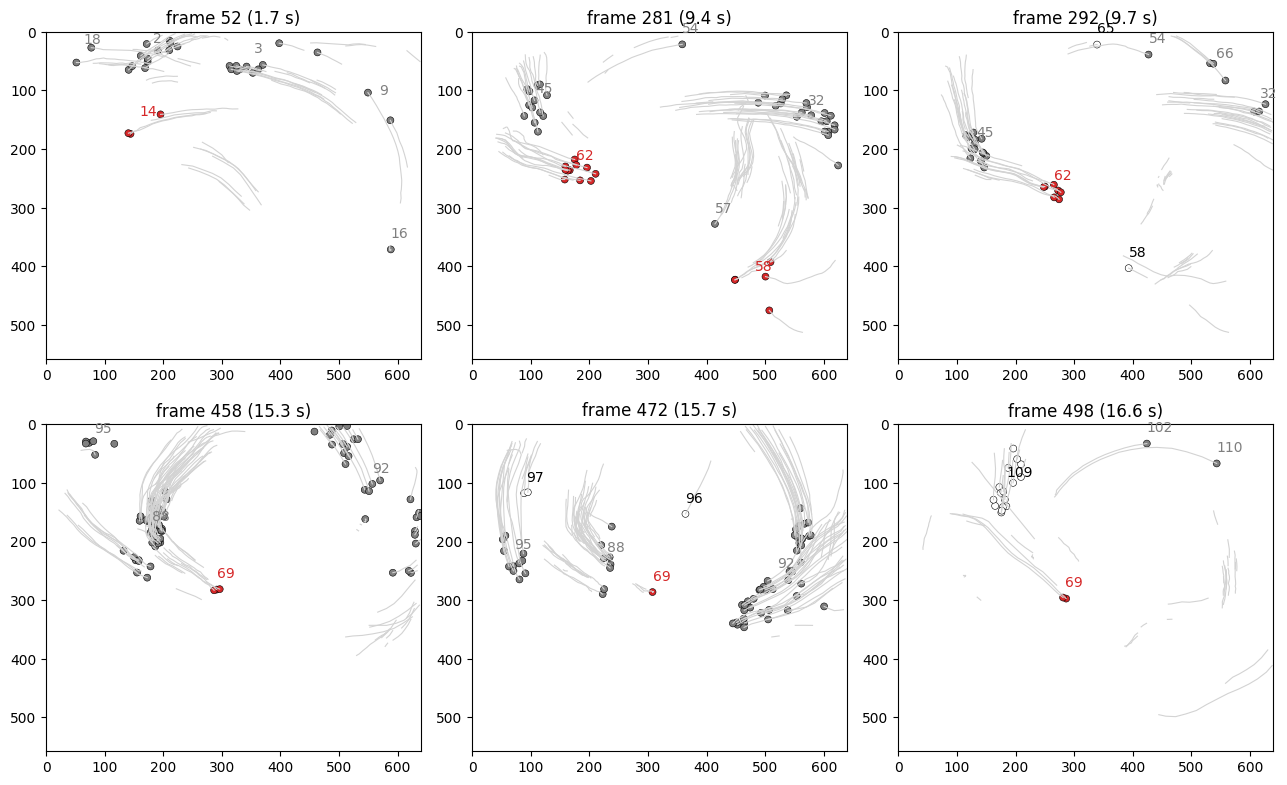

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [60]:
#dictionary creation
def pick_frames(data, flag="wavy", n=10):
    frames = np.sort(data.loc[data[flag], "frame"].unique())

    if len(frames) == 0:
        frames = np.sort(data["frame"].unique())

    if len(frames) <= n:
        return frames.astype(int).tolist()

    positions = np.linspace(0, len(frames) - 1, n, dtype=int)
    return frames[positions].astype(int).tolist()


FRAMES_TO_SHOW = pick_frames(OBJ, "wavy", n=10)
print("Showing frames:", FRAMES_TO_SHOW)

wavy_lookup = {
    (row.obj, row.frame): row.wavy
    for row in OBJ.itertuples()
}


def object_color(obj, frame):
    """Color based on object's classification at a given frame."""
    wavy = wavy_lookup.get((obj, frame))

    if wavy is None:
        return "white"
    if wavy:
        return "tab:red"
    return "tab:gray"

def plot_frame_grid(seg, frames):
    TRAIL_PLOT = 20
    x_min, x_max = seg["x"].min(), seg["x"].max()
    y_min, y_max = seg["y"].min(), seg["y"].max()

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    for ax, frame in zip(axes.flat, frames):
        #recent traj
        recent = seg[
            (seg["frame"] > frame - TRAIL_PLOT) &
            (seg["frame"] <= frame)
        ]

        for _, track in recent.groupby("track_id"):
            ax.plot(
                track["x"],
                track["y"],
                color="lightgray",
                lw=0.8
            )

        # Dots at current frame
        current = recent[recent["frame"] == frame]

        colors = [
            object_color(obj, frame)
            for obj in current["obj"]
        ]

        ax.scatter(
            current["x"],
            current["y"],
            c=colors,
            s=25,
            edgecolors="black",
            linewidths=0.4
        )

        for obj, points in current.groupby("obj"):
          color = object_color(obj, frame)

          ax.annotate(
              int(obj),
              (
                  points["x"].mean(),
                  points["y"].mean()-20
              ),
              color = "black" if color =="white" else color
          )

        ax.set_title(f"frame {frame} ({frame / FPS:.1f} s)")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_max, y_min)
        ax.set_aspect("equal")

    # Legend
    legend_items = [
        ("tab:red", "wavy (abnormal)"),
        ("tab:gray", "smooth"),
        ("white", "too short to judge"),
    ]

    for color, label in legend_items:
      axes.flat[0].scatter(
          [],
          [],
          c=color,
          edgecolor = "black",
          label = label
      )

      plt.tight_layout()
      plt.show()
plot_frame_grid(seg, FRAMES_TO_SHOW)

In [61]:
summary = (
    OBJ
    .groupby("obj")
    .agg(
        frames=("frame", "size"),
        wavy_frames=("wavy", "sum"),
        first=("frame", "min"),
        last=("frame", "max"),
        mean_dots=("n_dots", "mean"),
        mean_speed=("speed", "mean"),
        rushing_frames = ("rushing","sum")

    )
)

summary["wavy_frac"] = (
    summary["wavy_frames"] / summary["frames"]
)

summary["rushing_frac"] = summary["rushing_frames"]/summary["frames"]

summary = (
    summary[summary["frames"] >= MIN_OBJ_FRAMES]
    .sort_values("first")
)

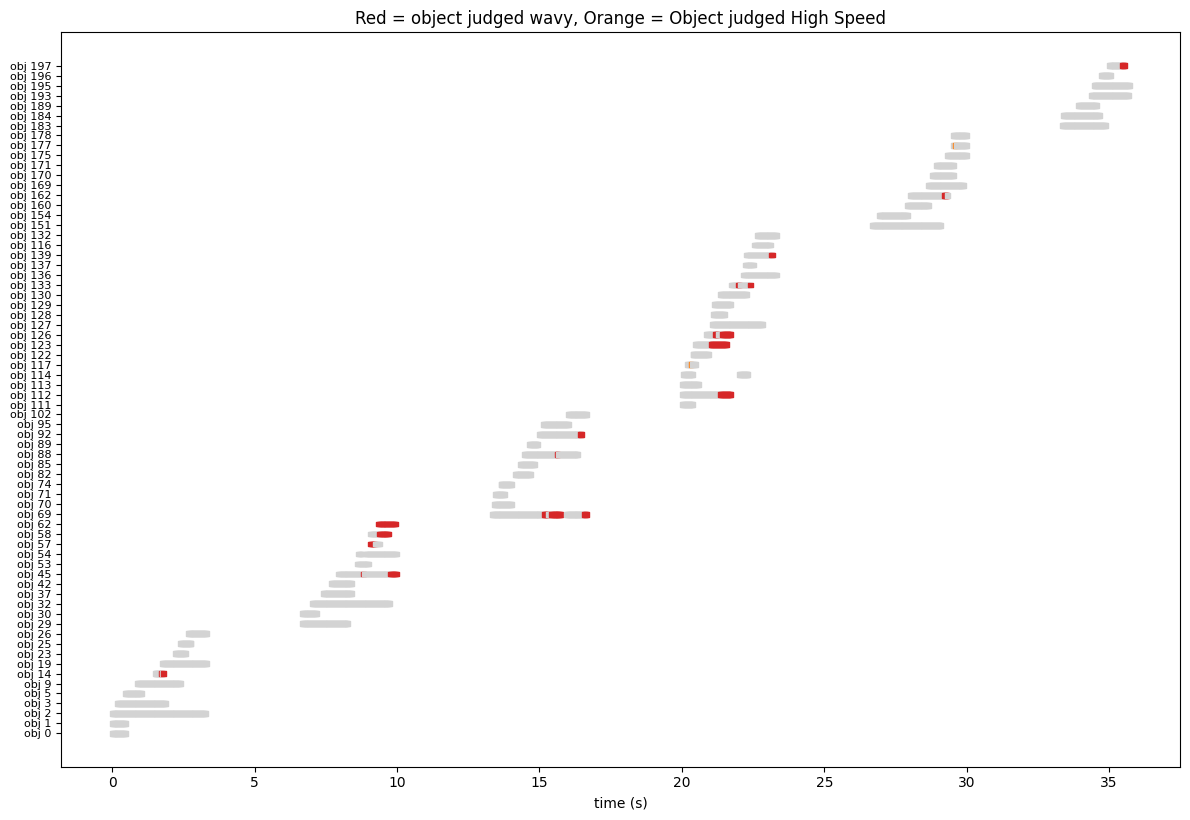

In [62]:
def plot_wavy_timeline(obj_data, summary):
    fig, ax = plt.subplots(
        figsize=(12, 0.1 * len(summary) + 1.5)
    )

    for row_index, obj in enumerate(summary.index):
        obj_frames = (
            obj_data[obj_data["obj"] == obj]
            .sort_values("frame")
        )

        Behavior_colors = {"rushing+wavy":"tab:purple",
                           "rushing": "tab:orange",
                           "wavy":"tab:red",
                           "normal":"lightgray",
                           }

        colors = obj_frames["behavior"].map(Behavior_colors)

        ax.scatter(
            obj_frames["frame"] / FPS,
            [row_index] * len(obj_frames),
            c=colors,
            s=12,
            marker="s"
        )

    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels(
        [f"obj {obj}" for obj in summary.index],
        fontsize=8
    )

    ax.set_xlabel("time (s)")
    ax.set_title("Red = object judged wavy, Orange = Object judged High Speed")
    plt.tight_layout()
    plt.show()


plot_wavy_timeline(OBJ, summary)